Exploratory Data Analysis (EDA)

• Objective
- In this notebook, we will explore the cleaned retail dataset to identify sales patterns, customer behavior, product performance, and business insights through data visualization.

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")

In [2]:
# Load the cleaned dataset

df = pd.read_csv("../data/OnlineRetail_cleaned.csv")

In [3]:
# Convert InvoiceDate into datetime format

df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

In [4]:
# Dataset shape

df.shape

(392692, 9)

In [5]:
# Display first five rows

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2022-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2022-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2022-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2022-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2022-12-01 08:26:00,3.39,17850,United Kingdom,20.34


• Revenue Overview

- Let's calculate some important business metrics to understand the overall performance of the retail store.

In [6]:
# Business metrics

total_revenue = df["TotalPrice"].sum()

total_orders = df["InvoiceNo"].nunique()

total_customers = df["CustomerID"].nunique()

total_products = df["Description"].nunique()

average_order_value = (
    df.groupby("InvoiceNo")["TotalPrice"]
      .sum()
      .mean()
)

In [7]:
# Revenue overview

summary = pd.DataFrame({
    "Metric": [
        "Total Revenue",
        "Total Orders",
        "Unique Customers",
        "Unique Products",
        "Average Order Value"
    ],
    "Value": [
        f"£{total_revenue:,.2f}",
        total_orders,
        total_customers,
        total_products,
        f"£{average_order_value:,.2f}"
    ]
})

summary

,Metric,Value
0,Total Revenue,"£8,887,208.89"
1,Total Orders,18532
2,Unique Customers,4338
3,Unique Products,3866
4,Average Order Value,£479.56


• Observation

- The business generated significant revenue during the observed period.
- The dataset contains thousands of completed orders from customers across multiple countries.
- These metrics provide a high-level understanding before performing detailed analysis.

• Top Countries by Revenue

- Let's identify the countries that generated the highest revenue.

In [8]:
# Revenue by country

country_revenue = (
    df.groupby("Country")["TotalPrice"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

country_revenue

Country
United Kingdom    7285024.644
Netherlands        285446.340
EIRE               265262.460
Germany            228678.400
France             208934.310
Australia          138453.810
Spain               61558.560
Switzerland         56443.950
Belgium             41196.340
Sweden              38367.830
Name: TotalPrice, dtype: float64

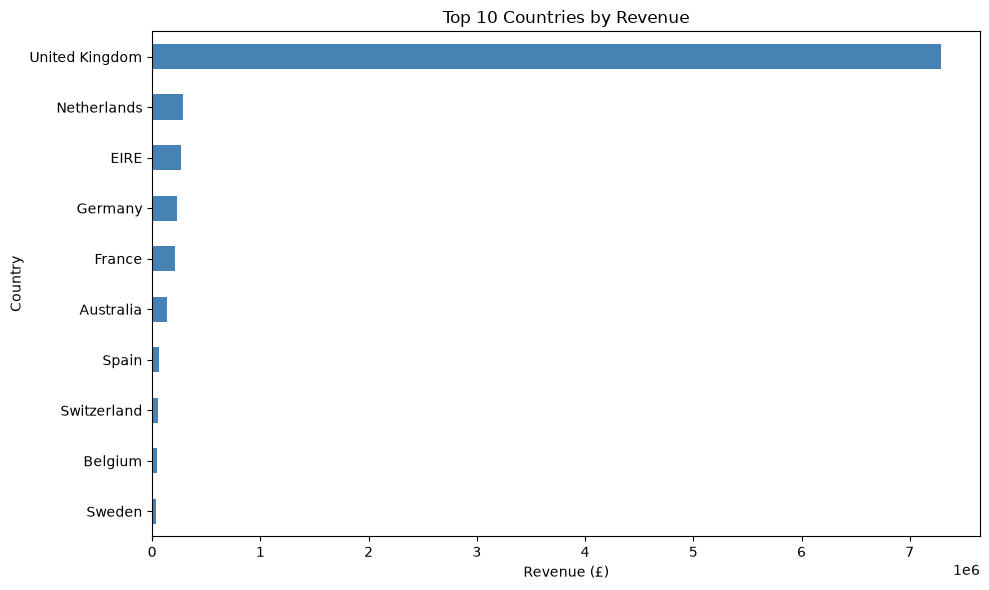

In [28]:
# Top 10 countries by revenue

plt.figure(figsize=(10,6))

country_revenue.sort_values().plot(
    kind="barh",
    color="steelblue"
)

plt.title("Top 10 Countries by Revenue")
plt.xlabel("Revenue (£)")
plt.ylabel("Country")

plt.tight_layout()
plt.show()

• Observation

- The **United Kingdom** contributes the highest revenue.
- Other European countries also contribute significantly.
- The business has a strong international customer base.

• Top Selling Products

- Let's identify the products that sold the highest quantity.

In [12]:
# Top selling products

top_products = (
    df.groupby("Description")["Quantity"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

top_products

Description
PAPER CRAFT , LITTLE BIRDIE           80995
MEDIUM CERAMIC TOP STORAGE JAR        77916
WORLD WAR 2 GLIDERS ASSTD DESIGNS     54319
JUMBO BAG RED RETROSPOT               46078
WHITE HANGING HEART T-LIGHT HOLDER    36706
ASSORTED COLOUR BIRD ORNAMENT         35263
PACK OF 72 RETROSPOT CAKE CASES       33670
POPCORN HOLDER                        30919
RABBIT NIGHT LIGHT                    27153
MINI PAINT SET VINTAGE                26076
Name: Quantity, dtype: int64

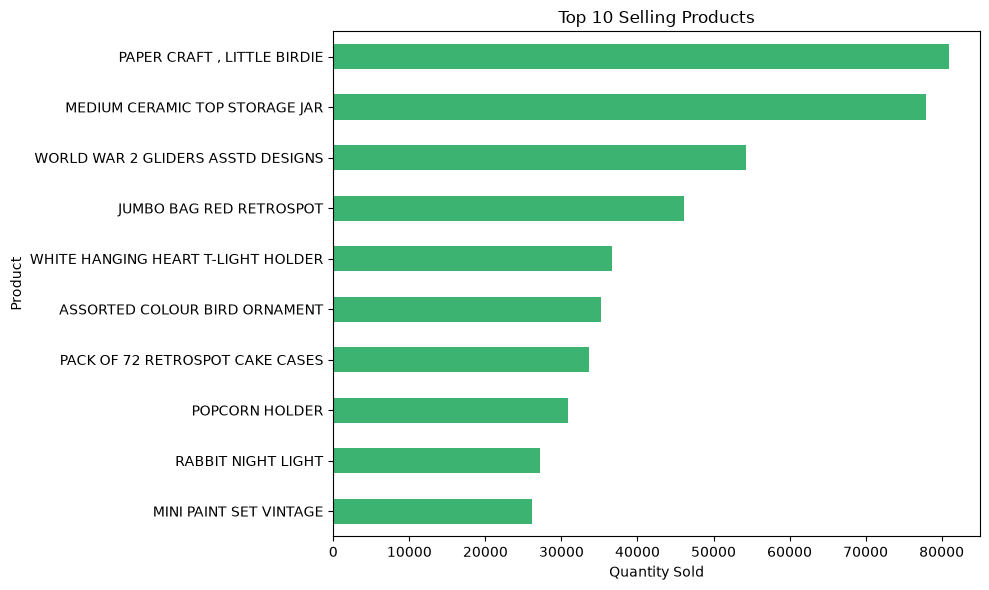

In [29]:
# Top selling products chart

plt.figure(figsize=(10,6))

top_products.sort_values().plot(
    kind="barh",
    color="mediumseagreen"
)

plt.title("Top 10 Selling Products")
plt.xlabel("Quantity Sold")
plt.ylabel("Product")

plt.tight_layout()
plt.show()

• Observation

- A few products account for a large number of sales.
- These products are important for inventory management and marketing strategies.

• Monthly Sales Trend

- Let's analyze how revenue changed over time.

In [14]:
# Create Year-Month column

df["YearMonth"] = (
    df["InvoiceDate"]
      .dt
      .to_period("M")
      .astype(str)
)

In [15]:
# Monthly revenue

monthly_sales = (
    df.groupby("YearMonth")["TotalPrice"]
      .sum()
)

monthly_sales

YearMonth
2022-12     570422.730
2023-01     568101.310
2023-02     446084.920
2023-03     594081.760
2023-04     468374.331
2023-05     677355.150
2023-06     660046.050
2023-07     598962.901
2023-08     644051.040
2023-09     950690.202
2023-10    1035642.450
2023-11    1156205.610
2023-12     517190.440
Name: TotalPrice, dtype: float64

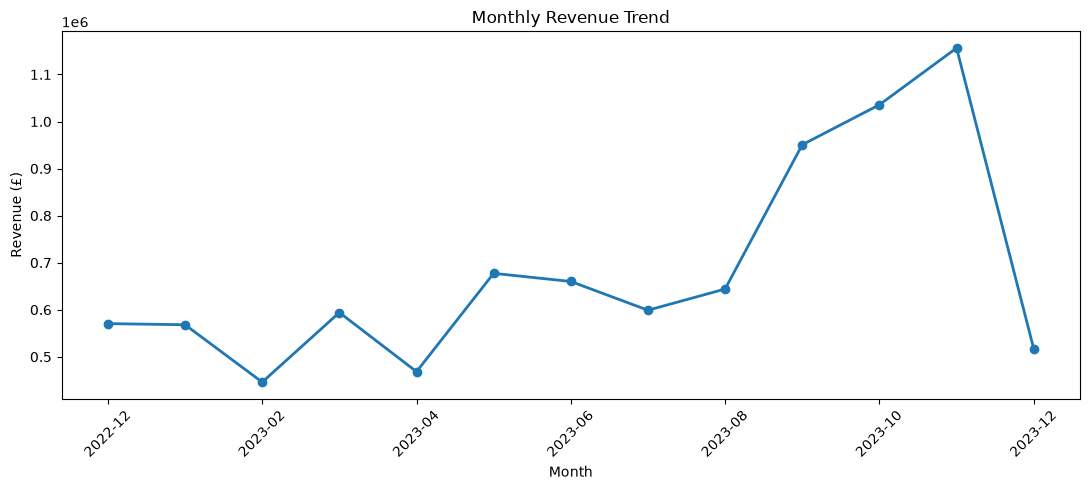

In [16]:
# Monthly sales trend

plt.figure(figsize=(11,5))

monthly_sales.plot(
    marker="o",
    linewidth=2
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue (£)")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

• Observation

- Revenue changes across different months.
- Peak sales months may indicate seasonal demand.
- This trend can help businesses plan inventory and marketing campaigns.

• Customer Analysis

- Let's analyze customer spending to understand purchasing behavior.

In [17]:
# Customer spending

customer_spending = (
    df.groupby("CustomerID")["TotalPrice"]
      .sum()
      .sort_values(ascending=False)
)

customer_spending.head()

CustomerID
14646    280206.02
18102    259657.30
17450    194390.79
16446    168472.50
14911    143711.17
Name: TotalPrice, dtype: float64

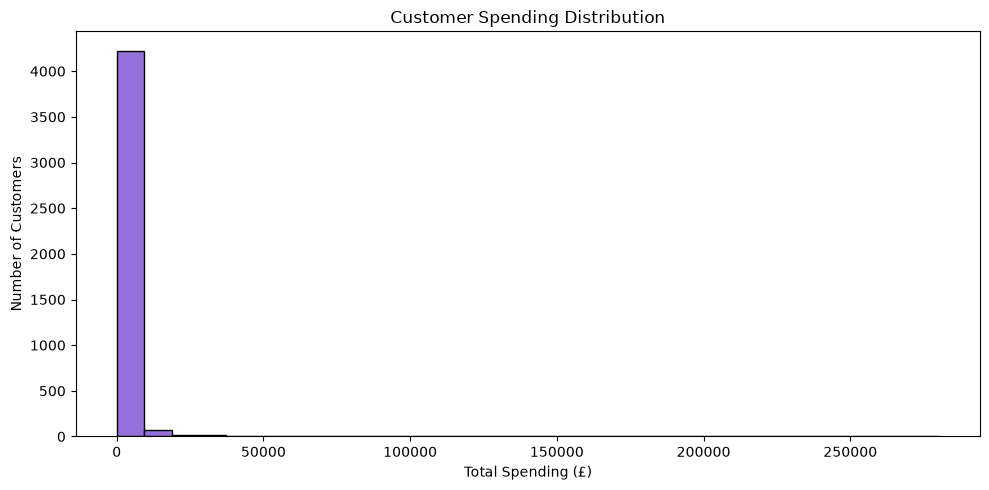

In [30]:
# Customer spending distribution

plt.figure(figsize=(10, 5))

plt.hist(
    customer_spending,
    bins=30,
    color="mediumpurple",
    edgecolor="black"
)

plt.title("Customer Spending Distribution")
plt.xlabel("Total Spending (£)")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

• Observation

- Most customers spend relatively small amounts.
- A small number of customers contribute significantly higher revenue.
- This pattern is common in retail businesses.

• Top Customers by Revenue

- Let's identify the customers who generated the highest revenue.

In [22]:
# Top 10 customers

top_customers = customer_spending.head(10)

top_customers

CustomerID
14646    280206.02
18102    259657.30
17450    194390.79
16446    168472.50
14911    143711.17
12415    124914.53
14156    117210.08
17511     91062.38
16029     80850.84
12346     77183.60
Name: TotalPrice, dtype: float64

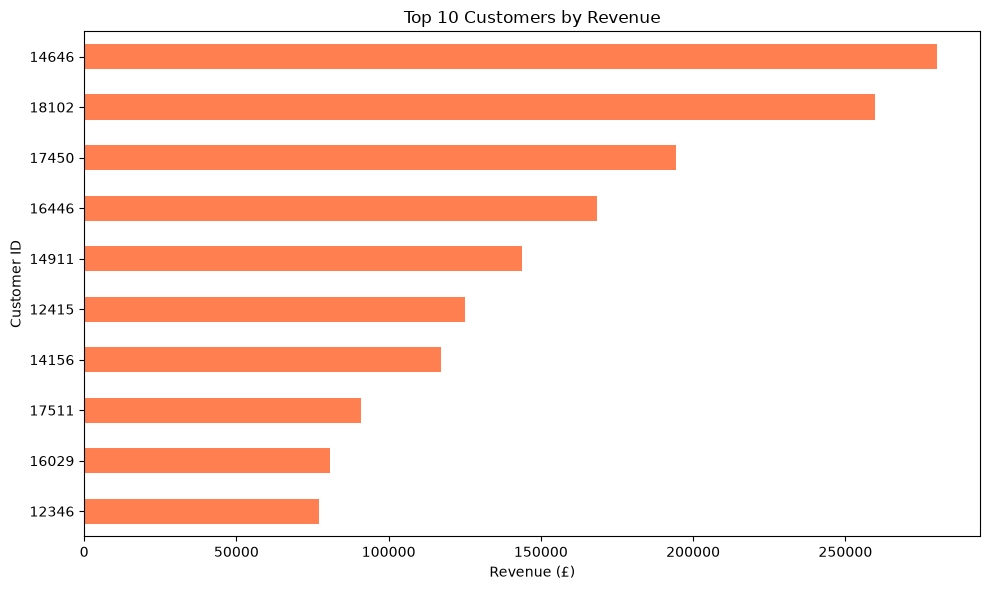

In [31]:
# Top customers chart

plt.figure(figsize=(10,6))

top_customers.sort_values().plot(
    kind="barh",
    color="coral"
)

plt.title("Top 10 Customers by Revenue")
plt.xlabel("Revenue (£)")
plt.ylabel("Customer ID")

plt.tight_layout()
plt.show()

• Observation

- A small group of customers contributes a large share of total revenue.
- These customers can be considered high-value customers.
- Businesses can target them with loyalty programs and personalized offers.

• Key Findings

- The United Kingdom generated the highest revenue.
- A few products contributed to most sales.
- Revenue varied across different months.
- Customer spending is uneven, with a small number of high-value customers.
- These insights provide a foundation for customer segmentation and business decision-making.